# Session 3: fitting 
Welcome to the third session of the Data Analysis workshop for Complex Systems course.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from func import *

sns.set_theme(style="whitegrid")


**fitting, Why?**  
To quantify relationships, make predictions, understand the data‑generating process, and simulate realistic scenarios.  
All fitting methods minimize a cost (error) to find the best model parameters.

## Linear least squares

For pairs $(x_i,y_i)$, find the line $y = a + b x$ that minimizes the sum of squared residuals  
$S = \sum (y_i - a - b x_i)^2$.

Setting derivatives to zero yields

$$
b = \frac{\text{Cov}(x,y)}{\text{Var}(x)} ,\qquad
a = \bar{y} - b\,\bar{x}.
$$

**Fit quality:**  
$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$ (proportion of variance explained).

True slope = 0.2
Manual:  a = 50.035, b = 0.2043
polyfit: a = 50.035, b = 0.2043


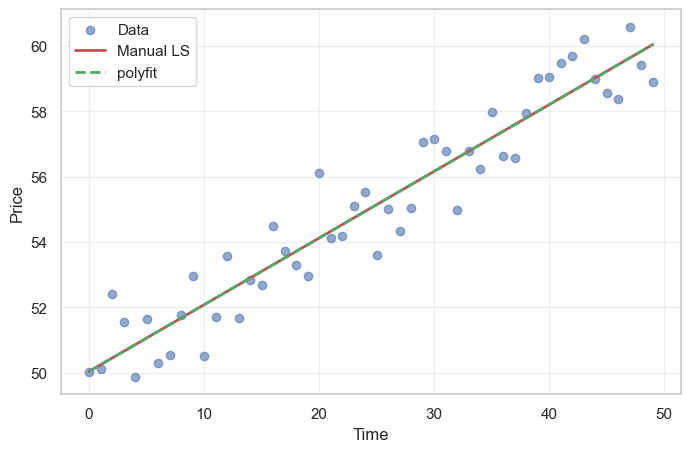

In [34]:
T = 50
t = np.arange(T)
slope_true = 0.2
noise = np.random.normal(0, 1.0, T)
price = 50 + slope_true * t + noise

x = t
y = price
n = len(x)
cov_xy = np.sum((x - x.mean()) * (y - y.mean())) / n   
var_x  = np.sum((x - x.mean())**2) / n                
b_manual = cov_xy / var_x
a_manual = y.mean() - b_manual * x.mean()

b_poly, a_poly = np.polyfit(x, y, 1)   

print(f"True slope = {slope_true}")
print(f"Manual:  a = {a_manual:.3f}, b = {b_manual:.4f}")
print(f"polyfit: a = {a_poly:.3f}, b = {b_poly:.4f}")

plt.figure(figsize=(8,5))
plt.scatter(t, price, alpha=0.6, label='Data')
plt.plot(t, a_manual + b_manual * t, 'r-', label='Manual LS', linewidth=2)
plt.plot(t, a_poly + b_poly * t, 'g--', label='polyfit', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## How to compute MLE – the general recipe

**Likelihood function.**  
For i.i.d. observations $x_1,\dots,x_n$, the joint density (probability of observing all $x_i$ together) is the product of the individual densities:

$$
L(\theta) = f(x_1;\theta)\cdot f(x_2;\theta)\cdots f(x_n;\theta) = \prod_{i=1}^{n} f(x_i;\theta).
$$
The maximum likelihood estimator $\hat\theta$ is obtained by maximising the (log‑)likelihood:
$L(\theta)$ is called the **likelihood**. We treat the data as fixed and vary $\theta$; the value that maximises $L(\theta)$ is the MLE.


$$
\hat\theta = \arg\max_\theta \;\ell(\theta), \qquad \ell(\theta) = \sum_{i=1}^n \ln f(x_i;\theta).
$$

Because the logarithm is monotonic, maximising $L(\theta)$ is equivalent to maximising the **log‑likelihood**.

**Two routes to the MLE:**

### 1. Analytical (closed‑form)
When $\frac{\partial\ell}{\partial\theta}=0$ can be solved by hand, we obtain an explicit formula (e.g. sample mean for Gaussian $\mu$, or sample mean for exponential scale).  
These are rare for most distributions.

### 2. Numerical optimisation (the universal method)
We define a function that returns the **negative log‑likelihood** $-\ell(\theta)$, then hand it to a numerical minimiser.  
Key steps:
- **initial guess** $\theta_0$,
- **bounds** or constraints if parameters have restricted domains (e.g. variance $>0$)


In [35]:
import numpy as np
from scipy.optimize import minimize
from scipy import stats

np.random.seed(42)
true_alpha, true_beta = 2.0, 1.5
data = np.random.gamma(shape=true_alpha, scale=true_beta, size=500)

def neg_log_likelihood(params):
    alpha, beta = params
    if alpha <= 0 or beta <= 0:
        return np.inf
    # stats.gamma.logpdf returns ln f(x; a, loc=0, scale=beta)
    return -np.sum(stats.gamma.logpdf(data, a=alpha, scale=beta))

initial_guess = [1.0, 1.0]

result = minimize(neg_log_likelihood, initial_guess,
                  bounds=[(1e-6, None), (1e-6, None)],
                  method='L-BFGS-B') #(L‑BFGS‑B allows bounds)


alpha_hat, beta_hat = result.x
print(f"Manual MLE:   shape = {alpha_hat:.4f}, scale = {beta_hat:.4f}")

scipy_alpha, _, scipy_beta = stats.gamma.fit(data, floc=0)  # floc=0 fixes location at 0
print(f"scipy.stats MLE: shape = {scipy_alpha:.4f}, scale = {scipy_beta:.4f}")

Manual MLE:   shape = 2.1975, scale = 1.3538
scipy.stats MLE: shape = 2.1975, scale = 1.3538


## Polynomial fitting - beyond a straight line: degree > 1

`polyfit(x, y, d)` fits a polynomial of degree \(d\):

$$ y \approx a_0 + a_1 x + a_2 x^2 + \dots + a_d x^d .
$$

It still uses **least squares** – it minimises the sum of squared residuals, but now finds \(d+1\) coefficients instead of two.  
Under the hood it solves a system of linear equations involving powers of \(x\).

**Trade‑off**

## Evaluating the fit – residuals, $R^2$, and standard error

**Residuals** $e_i = y_i - \hat{y}_i$ show the error for each point. A good fit has residuals scattered randomly around zero.

**$R^2$ (coefficient of determination)** – proportion of variance in $y$ explained by $x$. Closer to 1 is better.

$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$ (proportion of variance explained).

**Standard error of the estimate** – the typical size of a residual. It's $s = \sqrt{\frac{\sum e_i^2}{n-2}}$.

Degree 2 – R² = 0.9712, standard error = 8.4800


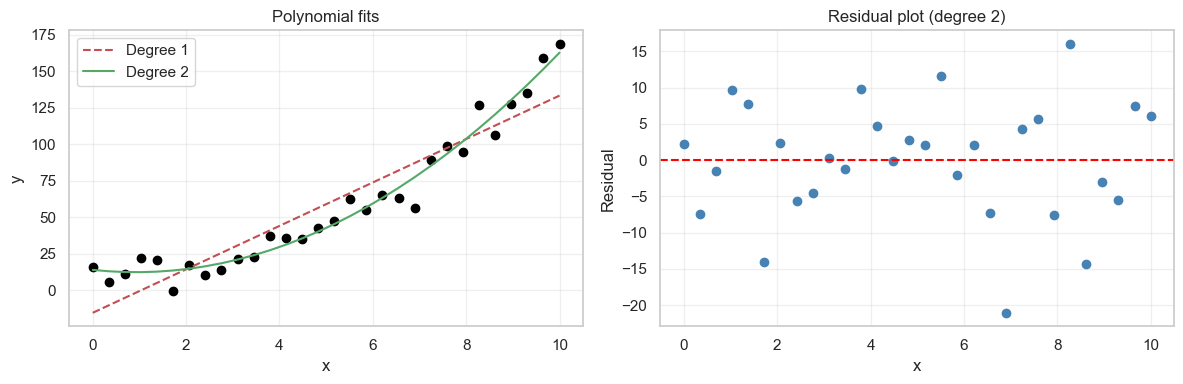

In [36]:
np.random.seed(0)
x = np.linspace(0, 10, 30)
y_true = 2 + 0.5*x + 1.5*x**2
y = y_true + np.random.normal(scale=8, size=len(x))

coeffs1 = np.polyfit(x, y, 1)
coeffs2 = np.polyfit(x, y, 2)
y1 = np.polyval(coeffs1, x)
y2 = np.polyval(coeffs2, x)

resid2 = y - y2

ss_res = np.sum(resid2**2)
ss_tot = np.sum((y - y.mean())**2)
R2 = 1 - ss_res / ss_tot
s = np.sqrt(ss_res / (len(x) - 3))   # k=3 parameters for degree 2

print(f"Degree 2 – R² = {R2:.4f}, standard error = {s:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
ax1.scatter(x, y, color='black')
ax1.plot(x, y1, 'r--', label='Degree 1')
ax1.plot(x, y2, 'g-', label='Degree 2')
ax1.legend(); ax1.set_title('Polynomial fits')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.grid(alpha=0.3)

ax2.scatter(x, resid2, color='steelblue')
ax2.axhline(0, color='red', linestyle='--')
ax2.set_title('Residual plot (degree 2)')
ax2.set_xlabel('x'); ax2.set_ylabel('Residual'); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## AIC – Akaike Information Criterion

Higher‑degree polynomials always reduce the residual sum of squares, but they may **overfit**.  
AIC balances goodness‑of‑fit with model complexity:

$$
\mathrm{AIC} = -2\ln L(\hat\theta) + 2k .
$$

For a least‑squares regression with normal errors, this simplifies to

$$
\mathrm{AIC} = n\ln\!\left(\frac{\mathrm{RSS}}{n}\right) + 2k ,
$$

where $ \mathrm{RSS} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 $ is the residual sum of squares and $ n $  is the sample size.  

where \(k\) is the number of parameters. **Lower AIC is better.**  
The penalty \(2k\) discourages adding unnecessary parameters.


In [39]:
np.random.seed(0)
x = np.linspace(0, 10, 30)
y_true = 2 + 0.5*x + 1.5*x**2
y = y_true + np.random.normal(scale=8, size=len(x))


degrees = [1,2 ,3,4, 5]
for d in degrees:
    coeffs = np.polyfit(x, y, d)
    y_pred = np.polyval(coeffs, x)
    rss = np.sum((y - y_pred)**2)
    k = d + 1
    aic = len(x) * np.log(rss / len(x)) + 2*k
    print(f"Degree {d}: RSS={rss:.1f}, AIC={aic:.1f}")

Degree 1: RSS=8279.9, AIC=172.6
Degree 2: RSS=1941.6, AIC=131.1
Degree 3: RSS=1900.3, AIC=132.5
Degree 4: RSS=1807.8, AIC=133.0
Degree 5: RSS=1805.8, AIC=134.9


**How R², RSS, and AIC are connected**

In a least‑squares regression, the model’s predictions are $ \hat{y}_i $.  
The **residual sum of squares** is  

$$
\mathrm{RSS} = \sum_{i=1}^n (y_i - \hat{y}_i)^2.
$$

From RSS we obtain two important numbers:

| Quantity | Formula | What it tells us |
|----------|---------|------------------|
| **R²** (coefficient of determination) | $1 - \frac{\mathrm{RSS}}{\mathrm{SS}_{\mathrm{tot}}}$   where $\mathrm{SS}_{\mathrm{tot}} = \sum (y_i - \bar{y})^2$ | Proportion of the total variance in  $ y $ that is explained by the model. Range: $(-\infty,1]$ (usually $[0,1]$ for a good model). |
| **AIC (regression)** | $ n\ln\!\left(\frac{\mathrm{RSS}}{n}\right) + 2k $ | A relative quality measure that **penalises** the number of parameters $ k $. Lower AIC is better. |

Both formulas contain RSS, but they serve different purposes:

- **R²** tells you “how much of the variation is captured” without accounting for how many parameters you used.
- **AIC** explicitly charges a penalty for each extra parameter. A model with many parameters can achieve a small RSS (and high R²) but a poor (large) AIC, indicating overfitting.

The AIC formula for regression is derived from the normal‑error likelihood:

$$
\ell(\hat{\boldsymbol{\beta}}, \hat{\sigma}^2) = -\frac{n}{2}\ln(2\pi) - \frac{n}{2}\ln(\hat{\sigma}^2) - \frac{n}{2},
\qquad \hat{\sigma}^2 = \frac{\mathrm{RSS}}{n}.
$$

Dropping constants that are the same for all models on the same data gives $\mathrm{AIC} \propto n\ln(\mathrm{RSS}/n) + 2k$.

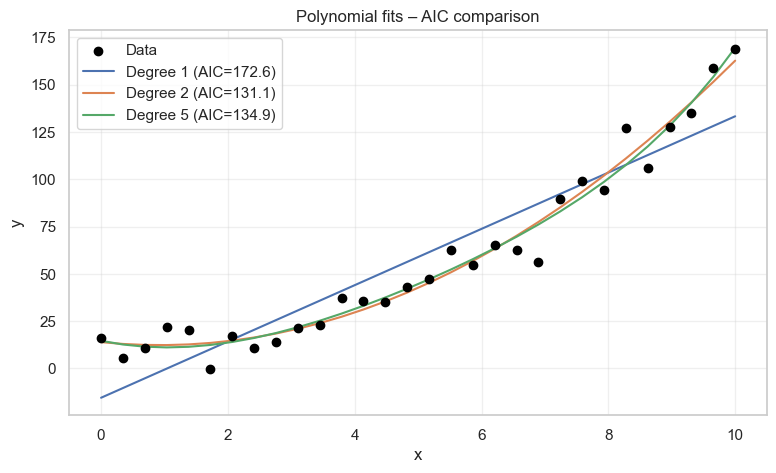

Degree 1: AIC = 172.6
Degree 2: AIC = 131.1
Degree 5: AIC = 134.9


In [40]:
np.random.seed(0)
x = np.linspace(0, 10, 30)
y_true = 2 + 0.5*x + 1.5*x**2
y = y_true + np.random.normal(scale=8, size=len(x))

degrees = [1, 2, 5]
aic_vals = []

plt.figure(figsize=(9,5))
plt.scatter(x, y, color='black', zorder=5, label='Data')

for d in degrees:
    coeffs = np.polyfit(x, y, d)               
    y_pred = np.polyval(coeffs, x)
    rss = np.sum((y - y_pred)**2)
    n = len(x)
    k = d + 1                                   
    aic = n * np.log(rss/n) + 2*k
    aic_vals.append(aic)
    plt.plot(x, y_pred, label=f'Degree {d} (AIC={aic:.1f})')

plt.legend()
plt.title('Polynomial fits – AIC comparison')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(alpha=0.3)
plt.show()

for d, aic in zip(degrees, aic_vals):
    print(f"Degree {d}: AIC = {aic:.1f}")

## Applying plateau models to data

The data captures where a quantity decays toward a constant plateau as $m$ increases.  
Three functional forms are plausible:

- Exponential plateau:  $y = c + A\,e^{-b\,m}$
- Power‑law plateau:    $y = c + A\,m^{-b}$
- Rational plateau:     $y = c + \dfrac{A}{m + b}$

We fit all three using your `fit_plateau_models` function, which does a grid‑search and selects the model with the **lowest AIC** (using the regression formula $n\ln(\text{RSS}/n) + 2k$).  

In [41]:
df = pd.read_csv('summary_ALL_m.csv')
df.head()

,m,plateau_m1_mean,plateau_m1_sem,plateau_m3_mean,plateau_m3_sem,reldiff_mean_pct,reldiff_sem_pct,C_mean,C_sem,L_mean,L_sem,lambda2_mean,lambda2_sem,k_mean,k_sem
0,5,0.048978,0.000019,0.070462,0.000211,43.864571,0.431500,0.040741,0.000577,2.979380,0.002264,2.762895,0.088081,9.95,3.298612e-16
1,10,0.046640,0.000013,0.061293,0.000122,31.416592,0.261065,0.060619,0.000435,2.556357,0.000965,7.158001,0.123755,19.80,6.597224e-16
2,15,0.046028,0.000017,0.058204,0.000092,26.455521,0.192055,0.079394,0.000400,2.327979,0.000896,11.771908,0.243788,29.55,1.319445e-15
3,20,0.045703,0.000014,0.056437,0.000070,23.486823,0.161278,0.095547,0.000405,2.166309,0.000701,15.753000,0.732606,39.20,1.319445e-15
4,25,0.045504,0.000014,0.055214,0.000064,21.338601,0.147768,0.110186,0.000353,2.061763,0.000425,21.137641,0.558001,48.75,0.000000e+00


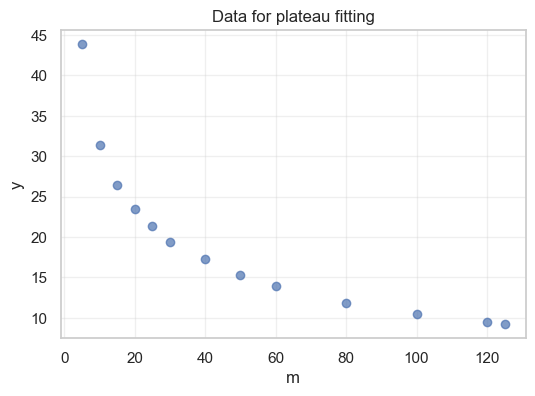

In [42]:
df = pd.read_csv('summary_ALL_m.csv')   
m = df['m'].values
y = df['reldiff_mean_pct'].values        

plt.figure(figsize=(6,4))
plt.scatter(m, y, alpha=0.7)
plt.xlabel('m')
plt.ylabel('y')
plt.title('Data for plateau fitting')
plt.grid(alpha=0.3)
plt.show()

In [44]:
result = fit_plateau_models(m, y)   

print("Best model:", result['best_name'])
print("Equation:  ", result['equation'])
print("Parameters:", result['params'])
print("AIC:       ", result['aic'])

Best model: power_plateau
Equation:   y = 0 + 89.9 m^(-0.452)
Parameters: (89.8873022549183, 0.45233707447721055, 0.0)
AIC:        -13.375324531235236


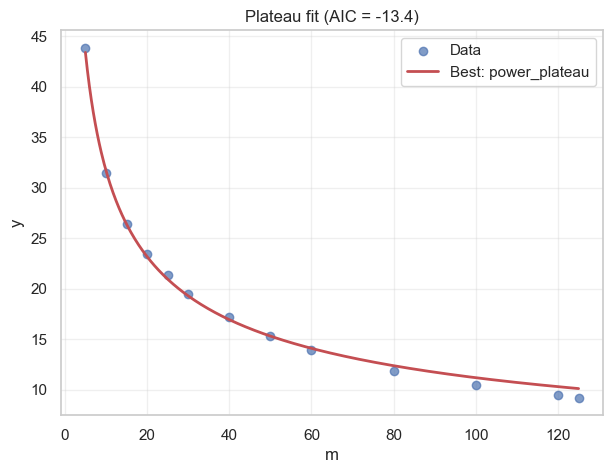

In [45]:
m_grid = result['m_grid']
y_grid = result['y_grid']

plt.figure(figsize=(7,5))
plt.scatter(m, y, alpha=0.7, label='Data')
plt.plot(m_grid, y_grid, 'r-', linewidth=2, label=f"Best: {result['best_name']}")
plt.xlabel('m')
plt.ylabel('y')
plt.title(f"Plateau fit (AIC = {result['aic']:.1f})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Inverse‑transform sampling – generating any distribution from uniform numbers

Recall the key idea: if $U \sim \text{Uniform}(0,1)$ and $F$ is the CDF of a target distribution, then

$$
X = F^{-1}(U)
$$

has exactly that target distribution.  



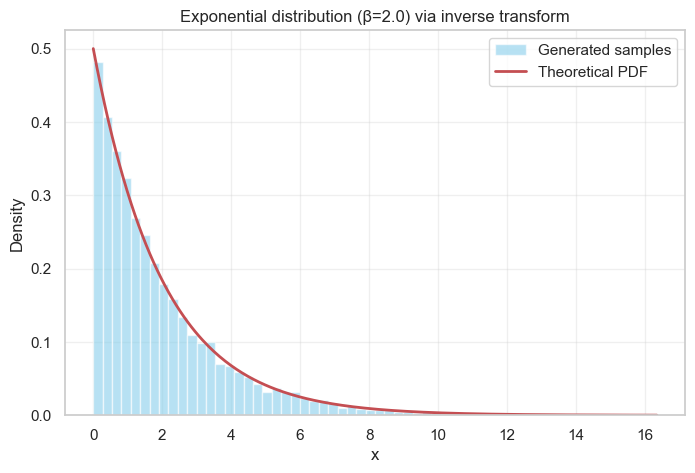

In [46]:
np.random.seed(42)
n = 10000
beta = 2.0                     

u = np.random.uniform(0, 1, n)
x = -beta * np.log(1 - u)      # same as -beta*log(u) because 1-U ~ Uniform(0,1)

plt.figure(figsize=(8,5))
plt.hist(x, bins=60, density=True, alpha=0.6, color='skyblue', label='Generated samples')
grid = np.linspace(0, np.max(x), 300)
plt.plot(grid, stats.expon.pdf(grid, scale=beta), 'r-', lw=2, label='Theoretical PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title(f'Exponential distribution (β={beta}) via inverse transform')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Shannon entropy – discrete and continuous

**Discrete case.**  
Given a probability distribution $\mathbf{p} = (p_1, p_2, \dots)$, $(\sum p_i = 1)$, the Shannon entropy (in nats) is

$$
H_{\text{disc}} = -\sum_{i} p_i \ln p_i .
$$

It quantifies the uncertainty: a uniform distribution has maximum entropy, while a perfectly localised outcome (one $p_i = 1)$ has zero entropy.

**Estimating entropy from a sample.**  
When we only have sample points, a common approach is to build a histogram. The discrete entropy of the **bin probabilities**    $p_b = (\frac{count}{total})$ gives

$$
H_{\text{hist}} = -\sum_{b} p_b \ln p_b .
$$

However, this quantity depends heavily on the number of bins $B$:

- If $B$ is too small, fine structure is lost.
- If $B$ is too large (each bin contains at most one point), then every occupied bin has probability $1/N$; the entropy becomes $\ln N$, regardless of the true distribution.


Thanks.